In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="Disease Progression")

print(X.head())
print(y.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: Disease Progression, dtype: float64


In [3]:
print(X.info())

print()

print(X.describe())

print()

print(X.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3

In [4]:
df = X.copy()
df["Disease Progression"] = y

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Disease Progression  
0 -0.002592  0.019907 -0.017646                151.0  
1 -0.039493 -0.068332 -0.092204                 75.0  
2 -0.002592  0.002861 -0.025930                141.0  
3  0.034309  0.022688 -0.009362                206.0  
4 -0.002592 -0.031988 -0.046641                135.0  


In [5]:
print(df.shape)

(442, 11)


In [6]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

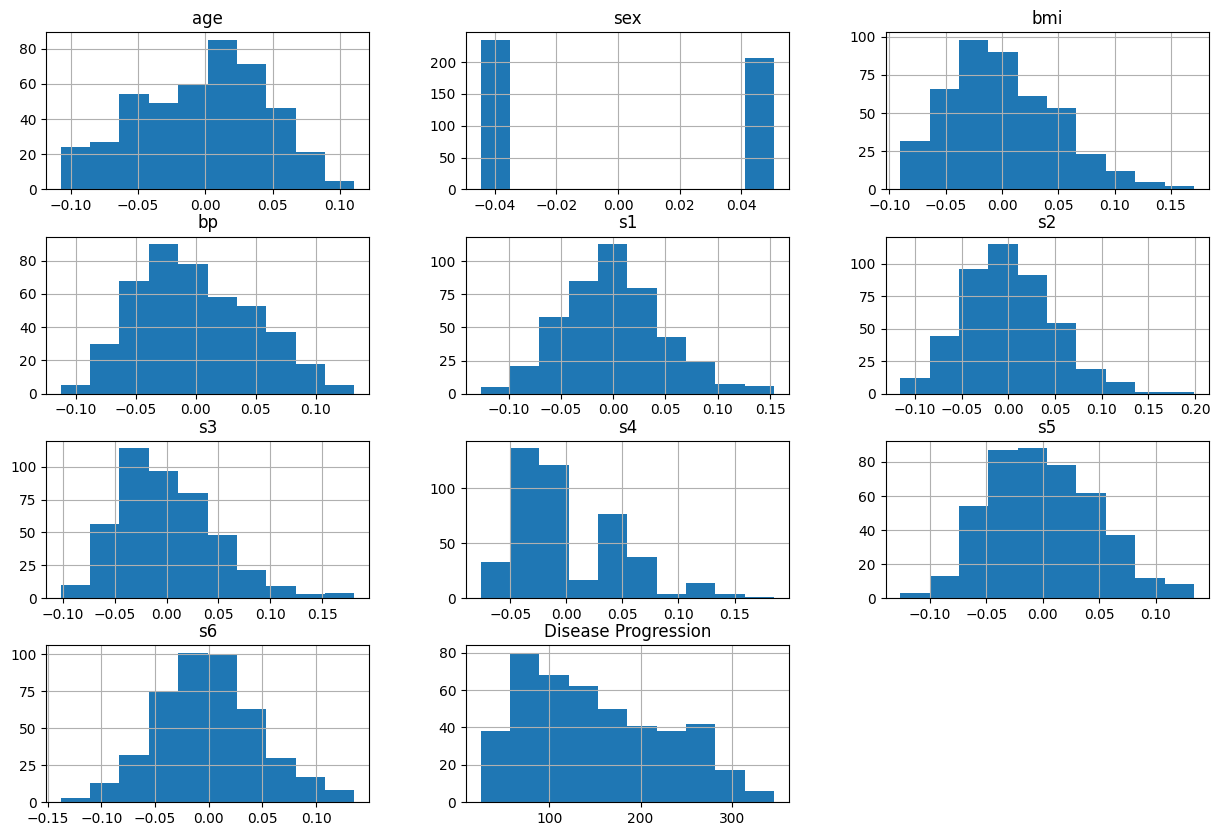

In [7]:
df.hist(figsize=(15,10))
plt.show()

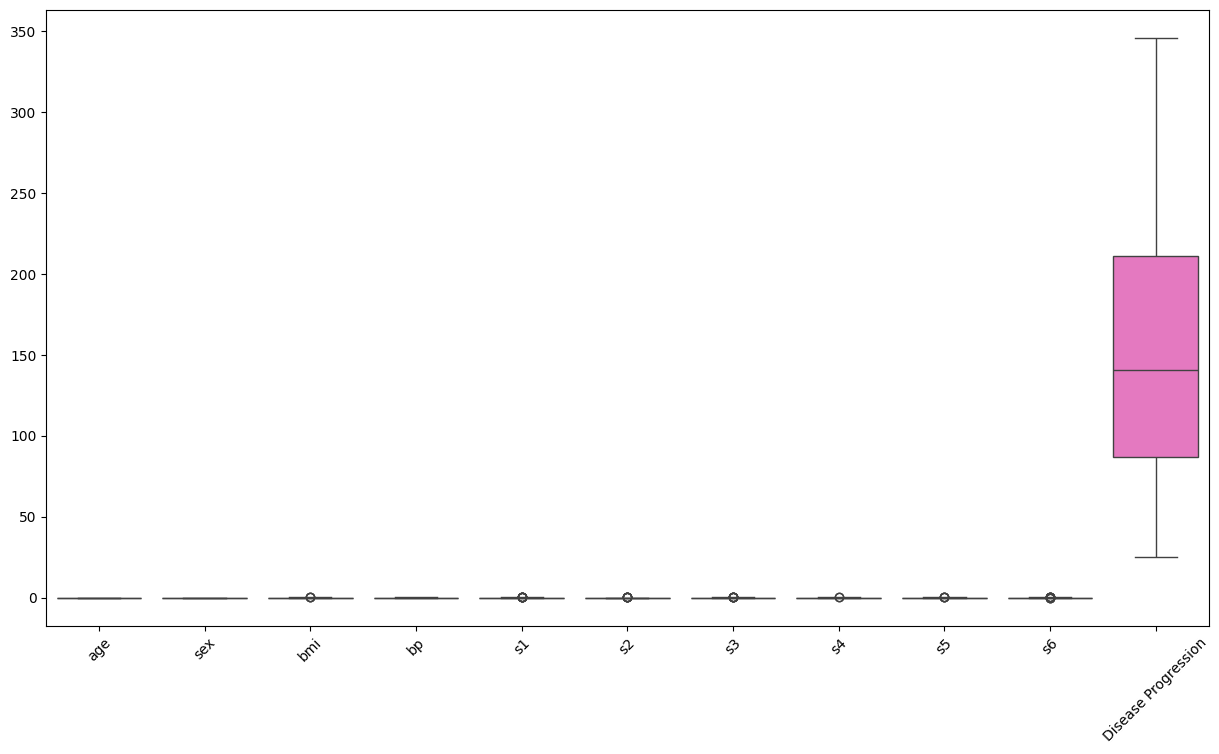

In [8]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

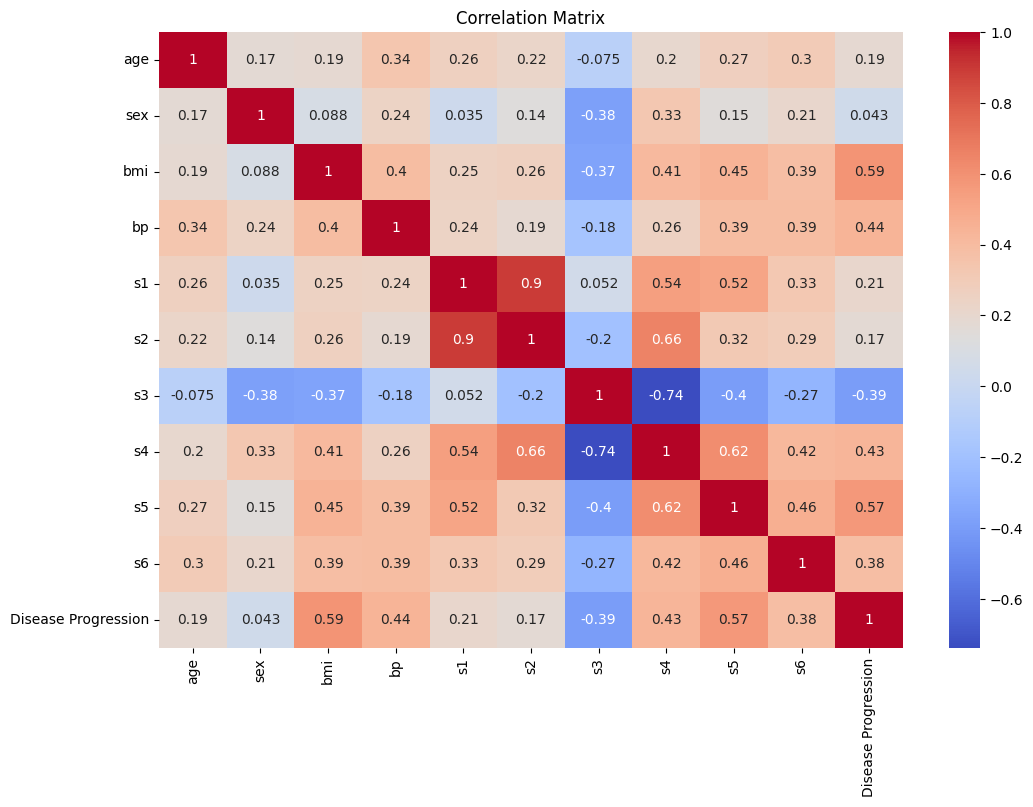

In [9]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.4526027629719195


In [14]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 42.79409467959994


In [15]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE =", rmse)

RMSE = 53.85344583676593


In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["Absolute"] = abs(importance["Coefficient"])

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print(importance)

  Feature  Coefficient    Absolute
4      s1  -931.488846  931.488846
8      s5   736.198859  736.198859
2     bmi   542.428759  542.428759
5      s2   518.062277  518.062277
3      bp   347.703844  347.703844
7      s4   275.317902  275.317902
1     sex  -241.964362  241.964362
6      s3   163.419983  163.419983
9      s6    48.670657   48.670657
0     age    37.904021   37.904021


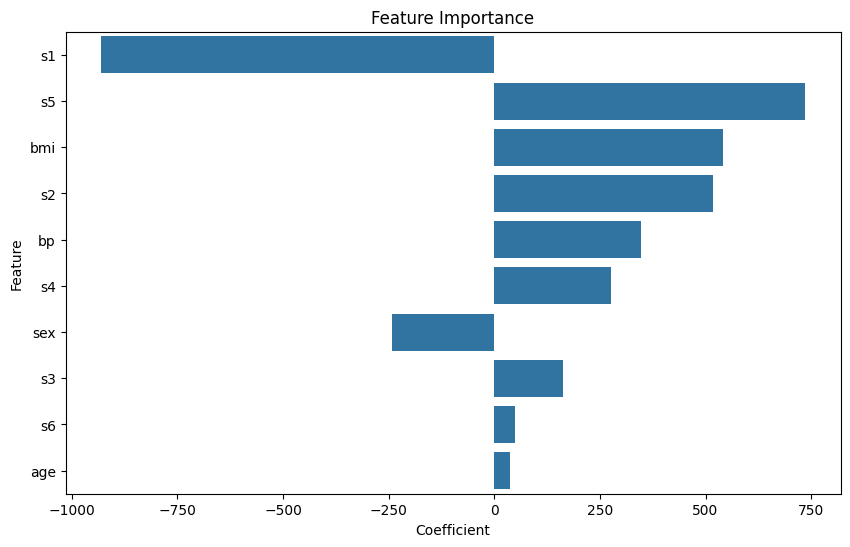

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

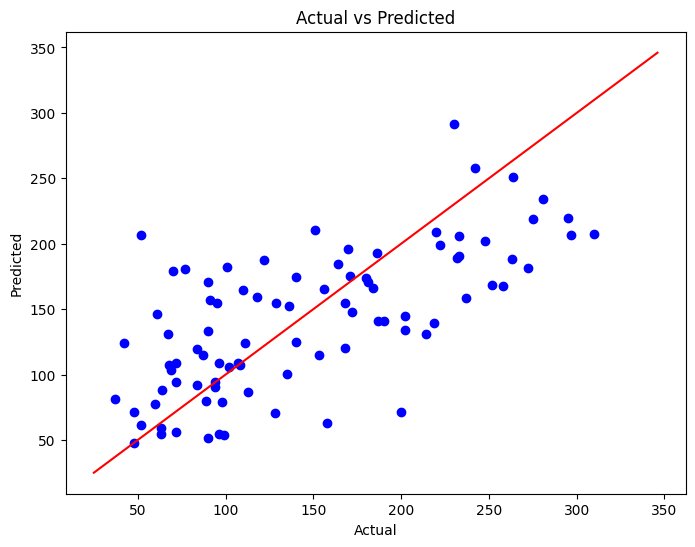

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            y_pred,
            color='blue')

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')

plt.show()

In [19]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head(20))

     Actual   Predicted
287   219.0  139.547558
211    70.0  179.517208
72    202.0  134.038756
321   230.0  291.417029
73    111.0  123.789659
418    84.0   92.172347
367   242.0  258.232389
354   272.0  181.337321
281    94.0   90.224113
148    96.0  108.633759
429    94.0   94.138657
78    252.0  168.434864
126    99.0   53.504789
113   297.0  206.630817
329   135.0  100.129259
427    67.0  130.666571
172   295.0  219.530715
268   264.0  250.780323
76    170.0  196.368835
116   275.0  218.575118


In [20]:
print("R2 Score :", r2)

print("MAE :", mae)

print("RMSE :", rmse)

print()

print("Top Influential Features")

print(importance)

R2 Score : 0.4526027629719195
MAE : 42.79409467959994
RMSE : 53.85344583676593

Top Influential Features
  Feature  Coefficient    Absolute
4      s1  -931.488846  931.488846
8      s5   736.198859  736.198859
2     bmi   542.428759  542.428759
5      s2   518.062277  518.062277
3      bp   347.703844  347.703844
7      s4   275.317902  275.317902
1     sex  -241.964362  241.964362
6      s3   163.419983  163.419983
9      s6    48.670657   48.670657
0     age    37.904021   37.904021
